# Knock Airport Weather Analysis

This notebook visualises weather data from Knock Airport, an international airport located approximately 5.6 km (3.5 mi) southwest of Charlestown, County Mayo, Ireland. The dataset spans from 31 July 1996 to 1 November 2025. It also contains a single early data point from 10 April 1996, 14:00, which will be removed as it disrupts the hourly pattern of the dataset.

---
## Planned Plots

We will generate the following **seven plots**:
1. Temperature at Knock Airport
2. Mean daily temperature
3. Mean monthly temperature
4. Hourly windspeed (note: some data is missing)
5. Rolling windspeed (24-hour average)
6. Maximum windspeed for each day
7. Monthly average of daily maximum windspeeds

--- 

Data Notes:
* The windspeed column contained missing and non-numeric entries.
* To prepare the data for plotting, all values were converted to numeric, with non-numeric entries replaced by NaN.
* This ensures that all analyses and visualizations are based on numeric values only.

### Import libraries

In [1]:
# Data handling and analysis
import pandas as pd

# Work with dates and times
from datetime import datetime, date

# Plotting libraries
from matplotlib import pyplot as plt
import matplotlib.dates as mdates  # tools for formatting time-based x-axes


### Data import and cleaning

In [2]:
# URL of the hourly weather data CSV file (Knock Airport)
url = "https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv"
# Read the CSV file
# The header in the CSV file is row 18 and the data entries for the weather starts from row 19
df = pd.read_csv(url, sep=",", header=18, skiprows=[0, 18])
df.head()

/tmp/ipykernel_95363/762708488.py:5: DtypeWarning: Columns (2,10,12,14,15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=",", header=18, skiprows=[0, 18])


,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,...,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
0,10-apr-1996 14:00,0,0.0,0,11.5,0,8.1,3.9,0.0,0,...,0,0,0,0,25,81,0.0,35000,32,5
1,31-jul-1996 08:00,0,0.0,0,11.5,0,11.1,10.7,0.0,0,...,0,0,0,0,25,82,0.0,40000,45,5
2,31-jul-1996 09:00,0,0.0,0,11.6,0,10.7,9.8,0.0,0,...,0,0,0,0,80,81,0.0,8000,32,7
3,31-jul-1996 10:00,0,0.0,0,12.9,0,11.3,9.8,0.0,0,...,0,0,0,0,25,82,0.0,28000,35,6
4,31-jul-1996 11:00,0,0.0,0,14.5,0,10.8,7.0,0.0,0,...,0,0,0,0,2,11,0.0,40000,40,6


In [3]:
# Remove the first entry (10 Apr 1996) — it breaks the hourly pattern
df = df.iloc[1:,]

In [4]:
# Check out the name of the columns
df.columns

Index(['date', 'ind', 'rain', 'ind.1', 'temp', 'ind.2', 'wetb', 'dewpt',
       'vappr', 'rhum', 'msl', 'ind.3', 'wdsp', 'ind.4', 'wddir', 'ww', 'w',
       'sun', 'vis', 'clht', 'clamt'],
      dtype='object')

In [5]:
# Check out the info of the pd.DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256433 entries, 1 to 256433
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    256433 non-null  object 
 1   ind     256433 non-null  int64  
 2   rain    256433 non-null  object 
 3   ind.1   256433 non-null  int64  
 4   temp    256433 non-null  float64
 5   ind.2   256433 non-null  int64  
 6   wetb    256433 non-null  float64
 7   dewpt   256433 non-null  float64
 8   vappr   256433 non-null  float64
 9   rhum    256433 non-null  int64  
 10  msl     256433 non-null  object 
 11  ind.3   256433 non-null  int64  
 12  wdsp    256433 non-null  object 
 13  ind.4   256433 non-null  int64  
 14  wddir   256433 non-null  object 
 15  ww      256433 non-null  object 
 16  w       256433 non-null  object 
 17  sun     256433 non-null  float64
 18  vis     256433 non-null  object 
 19  clht    256433 non-null  object 
 20  clamt   256433 non-null  object 
dtypes: float64

Refer to the official documentation ([see official documentation](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html)) for details on how to use the pandas.to_datetime() function, which converts a column containing date strings into datetime objects.

In [6]:
# Set the "date" column to a datetime object for further handling
df["date"] = pd.to_datetime(df["date"], format="%d-%b-%Y %H:%M", errors="coerce")
df.head()

,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,...,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
1,1996-07-31 08:00:00,0,0.0,0,11.5,0,11.1,10.7,0.0,0,...,0,0,0,0,25,82,0.0,40000,45,5
2,1996-07-31 09:00:00,0,0.0,0,11.6,0,10.7,9.8,0.0,0,...,0,0,0,0,80,81,0.0,8000,32,7
3,1996-07-31 10:00:00,0,0.0,0,12.9,0,11.3,9.8,0.0,0,...,0,0,0,0,25,82,0.0,28000,35,6
4,1996-07-31 11:00:00,0,0.0,0,14.5,0,10.8,7.0,0.0,0,...,0,0,0,0,2,11,0.0,40000,40,6
5,1996-07-31 12:00:00,0,0.0,0,14.4,0,10.9,7.3,0.0,0,...,0,0,0,0,1,82,0.0,40000,43,6


## Task 1 - Plot the temperature

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_95363/2692857617.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("Temperature ($^\circ$C)", fontsize=14, weight='bold')


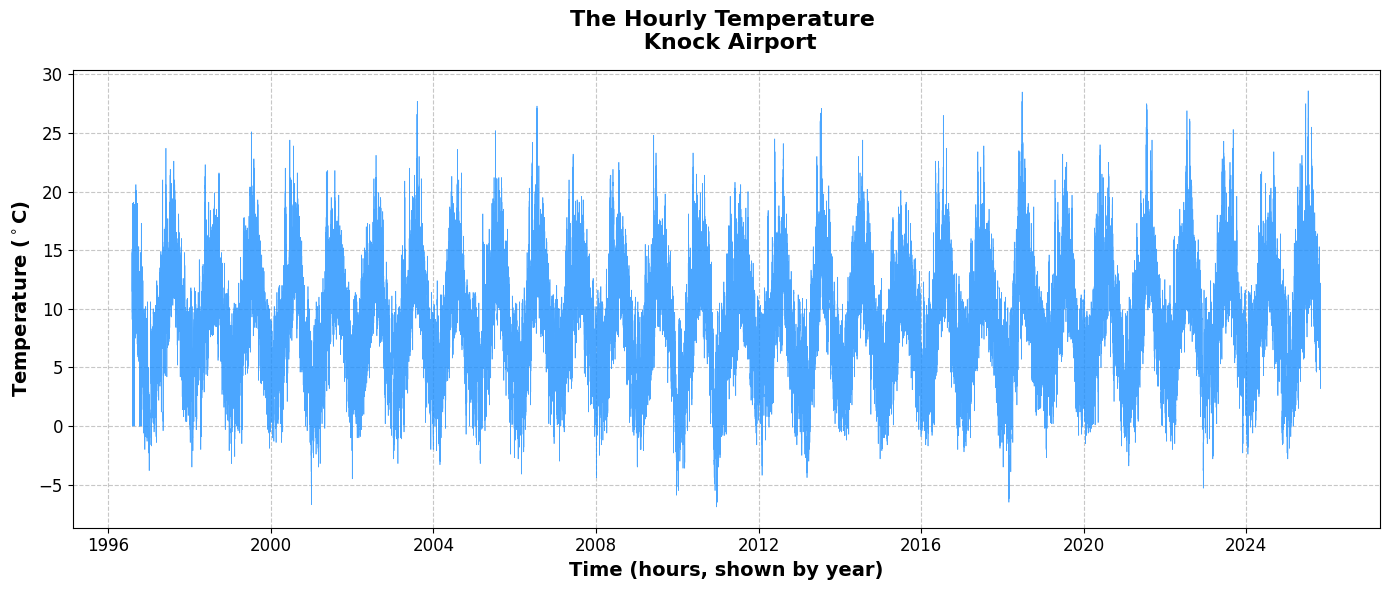

In [7]:
# Set the figure to a larger size for time series data
plt.figure(figsize=(14, 6))

# Plot hourly temperature
plt.plot(df["date"], df["temp"], color='dodgerblue', linewidth=0.5, alpha=0.8,)

# Set x-axis and y-axis font sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Set the names and the style of the x-axis, y-axis and the title
plt.ylabel("Temperature ($^\circ$C)", fontsize=14, weight='bold')
plt.xlabel("Time (hours, shown by year)", fontsize=14, weight='bold')
plt.title("The Hourly Temperature \n Knock Airport", fontsize=16, weight='bold', pad=15)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Task 2 - Plot the average daily temperature

<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_95363/2425925595.py:27: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("Temperature ($^\circ$C)", fontsize=14, weight='bold')


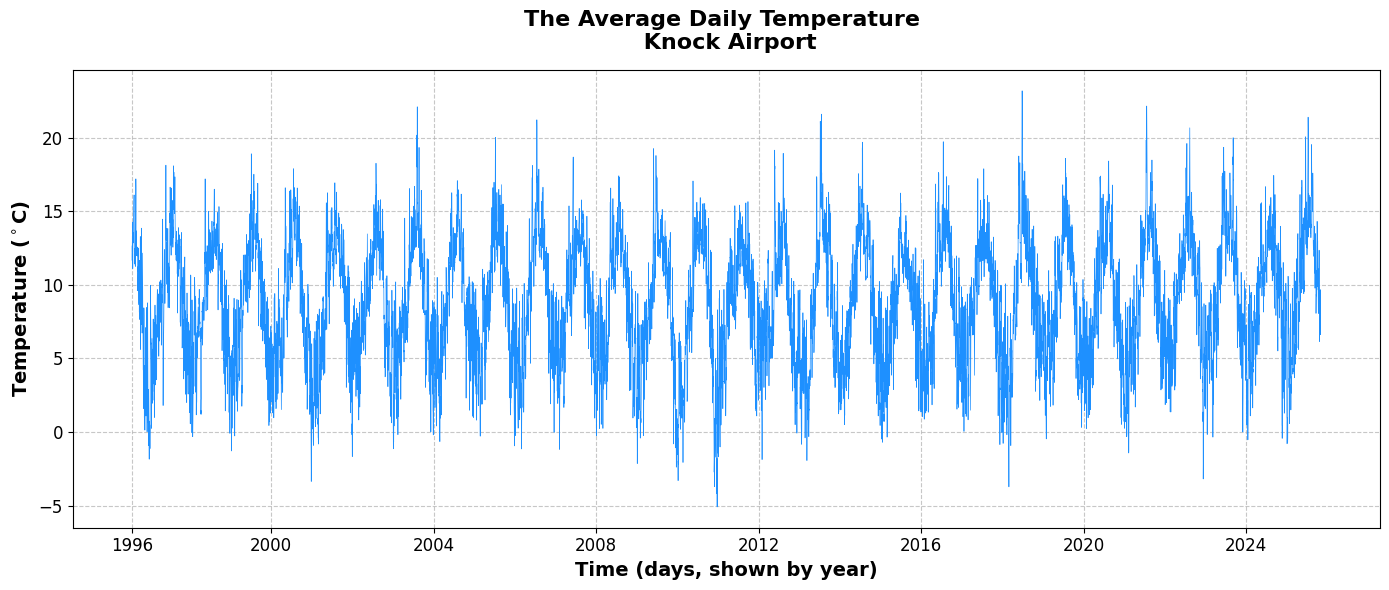

In [8]:
# Calculate the average temperature for each day
avg_temp_per_day = df.groupby(df["date"].dt.strftime("%Y-%m-%d"))["temp"].mean()

# Extract the year from each "YYYY-MM-DD" string in the index
years = [year_month_day.split("-")[0] for year_month_day in avg_temp_per_day.index]

# Define which years to show as x-axis ticks (every 4 years from 1996 to 2024)
years_to_plot = list(range(1996, 2025, 4))

# Find the positions in the index corresponding to the selected years
tick_positions = [years.index(str(y)) for y in years_to_plot]

# Set the figure to a larger size for time series data
plt.figure(figsize=(14, 6))

# Plot the average daily temperature
plt.plot(avg_temp_per_day.index, avg_temp_per_day.values, 
         color='dodgerblue', linewidth=0.5)

# Set x-axis ticks to selected years
plt.xticks(tick_positions, years_to_plot, fontsize=12)

# Set y-axis font size
plt.yticks(fontsize=12)

# Add labels and title with formatting
plt.ylabel("Temperature ($^\circ$C)", fontsize=14, weight='bold')
plt.xlabel("Time (days, shown by year)", fontsize=14, weight='bold')
plt.title("The Average Daily Temperature \n Knock Airport", fontsize=16, weight='bold', pad=15)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Task 3 - Plot the average monthly temperature

<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_95363/3779417321.py:27: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("Temperature ($^\circ$C)", fontsize=14, weight='bold')


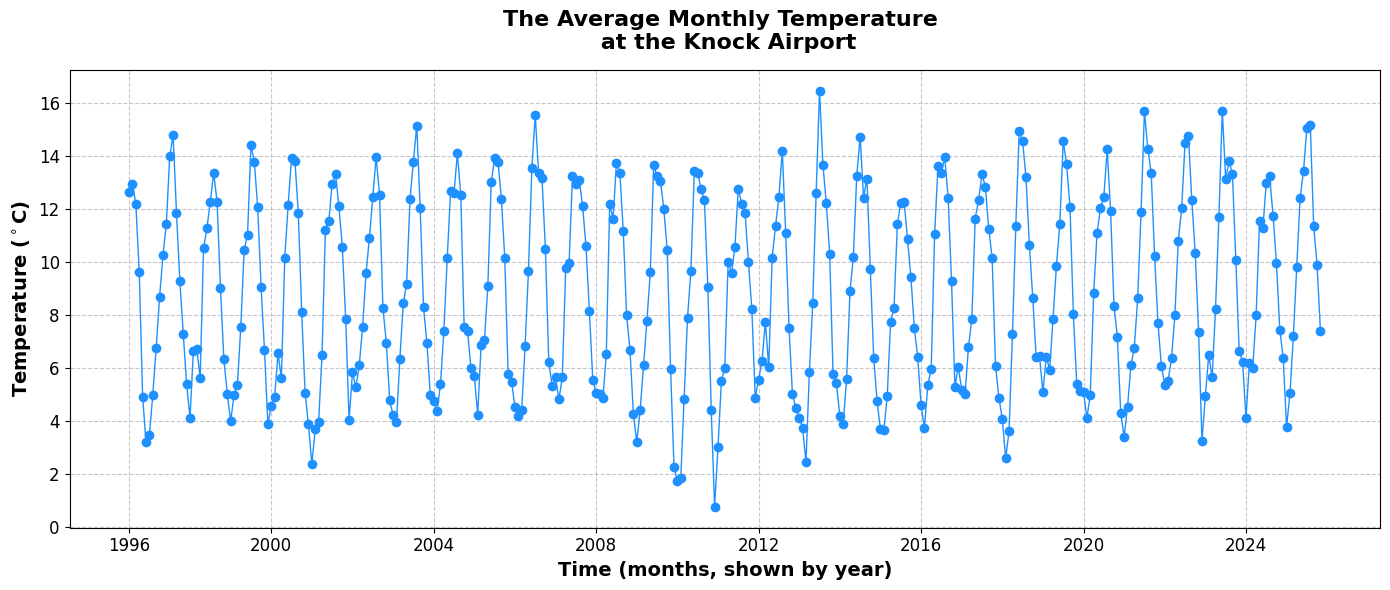

In [9]:
# Calculate the average temperature for each month
avg_temp_per_month = df.groupby(df["date"].dt.strftime("%Y-%m"))["temp"].mean()

# Extract the year from each "YYYY-MM" string in the index
years = [year_month.split("-")[0] for year_month in avg_temp_per_month.index]

# Define which years to show as x-axis ticks (every 4 years from 1996 to 2024)
years_to_plot = list(range(1996, 2025, 4))

# Find the positions in the index corresponding to the selected years
tick_positions = [years.index(str(y)) for y in years_to_plot]

# Set the figure to a larger size for time series data
plt.figure(figsize=(14, 6))

# Plot the average monthly temperature
plt.plot(avg_temp_per_month.index, avg_temp_per_month.values, 
         color='dodgerblue', linewidth=1, marker="o")

# Set x-axis ticks to selected years
plt.xticks(tick_positions, years_to_plot, fontsize=12)

# Set y-axis font size
plt.yticks(fontsize=12)

# Add axis labels
plt.ylabel("Temperature ($^\circ$C)", fontsize=14, weight='bold')
plt.xlabel("Time (months, shown by year)", fontsize=14, weight='bold')

# Add a title 
plt.title("The Average Monthly Temperature \n at the Knock Airport", 
          fontsize=16, weight='bold', pad=15)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Task 4 - Plot the windspeed

The hourly windspeed column currently has a data type of object, indicating it contains a mix of values, such as strings and integers. For plotting and numerical analysis, only numeric values (integers or floats) are required. Therefore, the column will be cleaned to retain only numeric entries and converted to float type.

In [10]:
# Set the values in the wdsp column to numeric values
# All non-numeric values will become NaN
numeric_df = df.wdsp.apply(pd.to_numeric, errors='coerce')
# Find rows where wdsp became NaN
non_numeric_rows = df[numeric_df.isna()][["wdsp"]]
# Here are the list of indexes from the numeric_df that do not contain numberic values and were converted to NaN
non_numeric_rows.index

Index([    39,   1398,   1795,   1796,   1797,   1798,   1799,   1800,   1801,
         1802,   1818,   1819,   1820,   1821,   1822,   1823,   1824,   1825,
         1834,   1835,   1836,   1837,   1838,   1839,   1840,   1841,   1842,
         1843,   1844,   1845,   1846,   1847,   1848,   1849,   1850,   1865,
         1866,   1867,   1869,   2022,   2026,   2027,   2028,   2030,   2785,
         2936, 108039, 108040, 108041, 108042],
      dtype='int64')

In [11]:
# Create a copy of the original df
df_wdsp = df.copy()
# Replace the wdsp column with new numeric columns without any other data types
df_wdsp["wdsp"] = numeric_df.to_list()

# Here you can check the non-numeric values in the wdsp column
df["wdsp"].iloc[non_numeric_rows.index,]

40         7
1399      18
1796        
1797        
1798        
1799        
1800        
1801        
1802        
1803      11
1819        
1820        
1821        
1822        
1823        
1824        
1825        
1826       9
1835        
1836        
1837        
1838        
1839        
1840        
1841        
1842        
1843        
1844        
1845        
1846        
1847        
1848        
1849        
1850        
1851      11
1866        
1867        
1868       6
1870       4
2023      20
2027        
2028        
2029      15
2031      14
2786      20
2937       5
108040      
108041      
108042      
108043    17
Name: wdsp, dtype: object

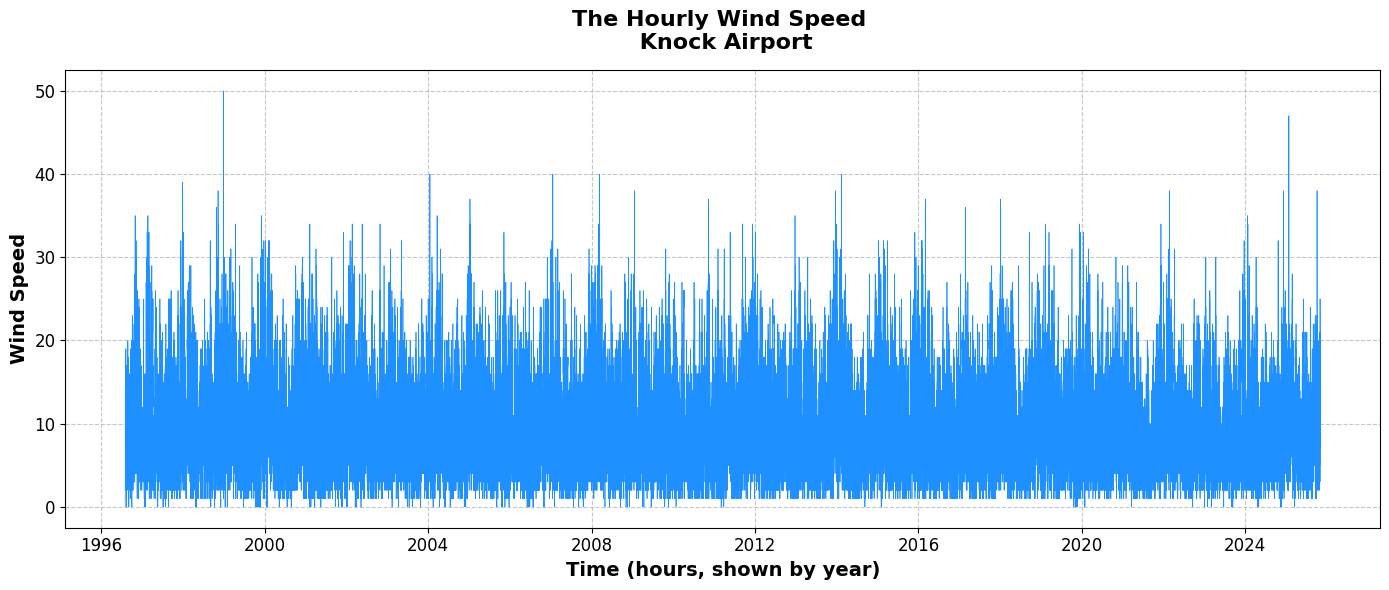

In [12]:
# Set the figure size larger for better visibility of time series data
plt.figure(figsize=(14, 6))

# Plot hourly wind speed over time
plt.plot(df_wdsp["date"], df_wdsp["wdsp"], color='dodgerblue', linewidth=0.5)

# Set font size for x and y axis tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add axis labels
plt.ylabel("Wind Speed", fontsize=14, weight='bold')
plt.xlabel("Time (hours, shown by year)", fontsize=14, weight='bold')

# Add a title 
plt.title("The Hourly Wind Speed \n Knock Airport", fontsize=16, weight='bold', pad=15)

# Add a light grid for improved readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Task 5 - Plot the rolling windspeed

Refer to the official documentation ([see official documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html)) for details on how to use the pandas.rolling() function, which allows to calculate an average of the values in column or row with a rolling frame that can be set to different sizes.

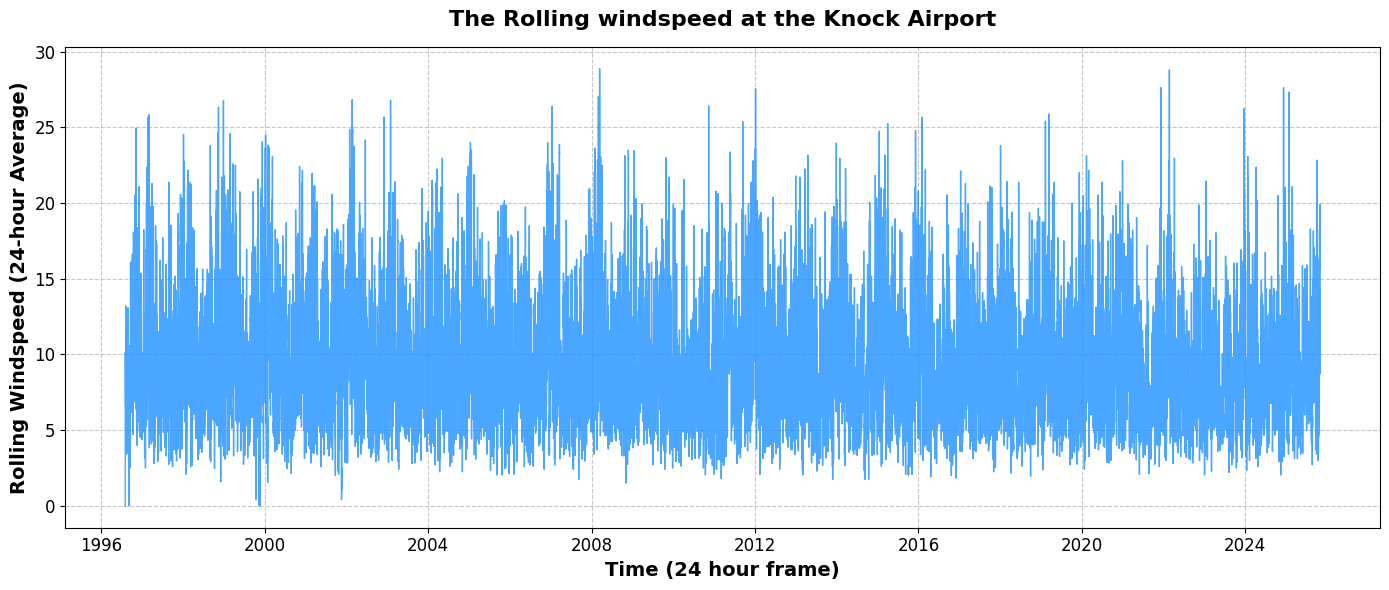

In [13]:
# Compute a 24-hour rolling average of windspeed
rolling_wdsp = df_wdsp["wdsp"].rolling(24, min_periods=1).mean()

# Extract the year from each datetime in the index for tick placement
years = [adate.year for adate in df_wdsp["date"]]

# Define years to display on x-axis (every 4 years from 1996 to 2024)
years_to_plot = list(range(1996, 2025, 4))

# Find positions in the index corresponding to the selected years
tick_positions = [years.index(y) for y in years_to_plot]

# Set figure size for better visibility
plt.figure(figsize=(14, 6))

# Plot the rolling windspeed with a semi-transparent line
plt.plot(df_wdsp["date"], rolling_wdsp.values, 
         color='dodgerblue', linewidth=1, alpha=0.8)

# Set font size for tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add axis labels 
plt.ylabel("Rolling Windspeed (24-hour Average)", fontsize=14, weight='bold')
plt.xlabel("Time (24 hour frame)", fontsize=14, weight='bold')

# Add a title 
plt.title("The Rolling windspeed at the Knock Airport", fontsize=16, weight='bold', pad=15)

# Add a light grid for improved readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Task 6 - Plot the max windspeed for each day

In [14]:
df_wdsp.head()

,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,...,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
1,1996-07-31 08:00:00,0,0.0,0,11.5,0,11.1,10.7,0.0,0,...,0,0.0,0,0,25,82,0.0,40000,45,5
2,1996-07-31 09:00:00,0,0.0,0,11.6,0,10.7,9.8,0.0,0,...,0,0.0,0,0,80,81,0.0,8000,32,7
3,1996-07-31 10:00:00,0,0.0,0,12.9,0,11.3,9.8,0.0,0,...,0,0.0,0,0,25,82,0.0,28000,35,6
4,1996-07-31 11:00:00,0,0.0,0,14.5,0,10.8,7.0,0.0,0,...,0,0.0,0,0,2,11,0.0,40000,40,6
5,1996-07-31 12:00:00,0,0.0,0,14.4,0,10.9,7.3,0.0,0,...,0,0.0,0,0,1,82,0.0,40000,43,6


In [15]:
df_wdsp.groupby(df["date"].dt.strftime("%Y-%m-%d"))["wdsp"].max()

date
1996-07-31     0.0
1996-08-01    14.0
1996-08-02    13.0
1996-08-03    10.0
1996-08-04    18.0
              ... 
2025-10-28    15.0
2025-10-29    15.0
2025-10-30    25.0
2025-10-31    20.0
2025-11-01     7.0
Name: wdsp, Length: 10686, dtype: float64

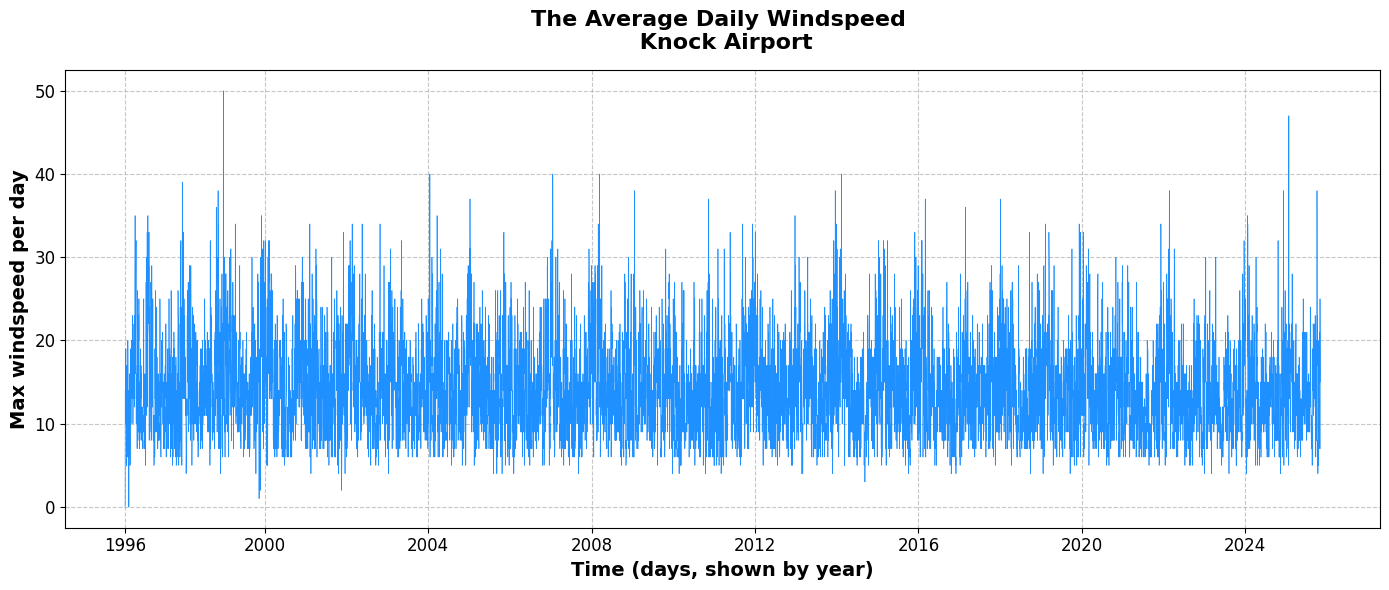

In [16]:
# Compute the maximum windspeed for each day
max_wdsp_per_day = df_wdsp.groupby(df["date"].dt.strftime("%Y-%m-%d"))["wdsp"].max()

# Extract the year from each "YYYY-MM-DD" string in the index
years = [year_month_day.split("-")[0] for year_month_day in max_wdsp_per_day.index]

# Define which years to show as x-axis ticks (every 4 years from 1996 to 2024)
years_to_plot = list(range(1996, 2025, 4))

# Find the positions in the index corresponding to the selected years
tick_positions = [years.index(str(y)) for y in years_to_plot]

# Set figure size for better visibility
plt.figure(figsize=(14, 6))

# Plot daily maximum windspeed
plt.plot(max_wdsp_per_day.index, max_wdsp_per_day.values, 
         color='dodgerblue', linewidth=0.5)

# Set x-axis ticks to selected years
plt.xticks(tick_positions, years_to_plot, fontsize=12)

# Set y-axis font size
plt.yticks(fontsize=12)

# Add axis labels with bold font
plt.ylabel("Max windspeed per day", fontsize=14, weight='bold')
plt.xlabel("Time (days, shown by year)", fontsize=14, weight='bold')

# Add a title 
plt.title("The Average Daily Windspeed \n Knock Airport", fontsize=16, weight='bold', pad=15)

# Add a light grid for improved readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Task 7 - Plot the monthly average of daily maximum windspeeds at knock airport

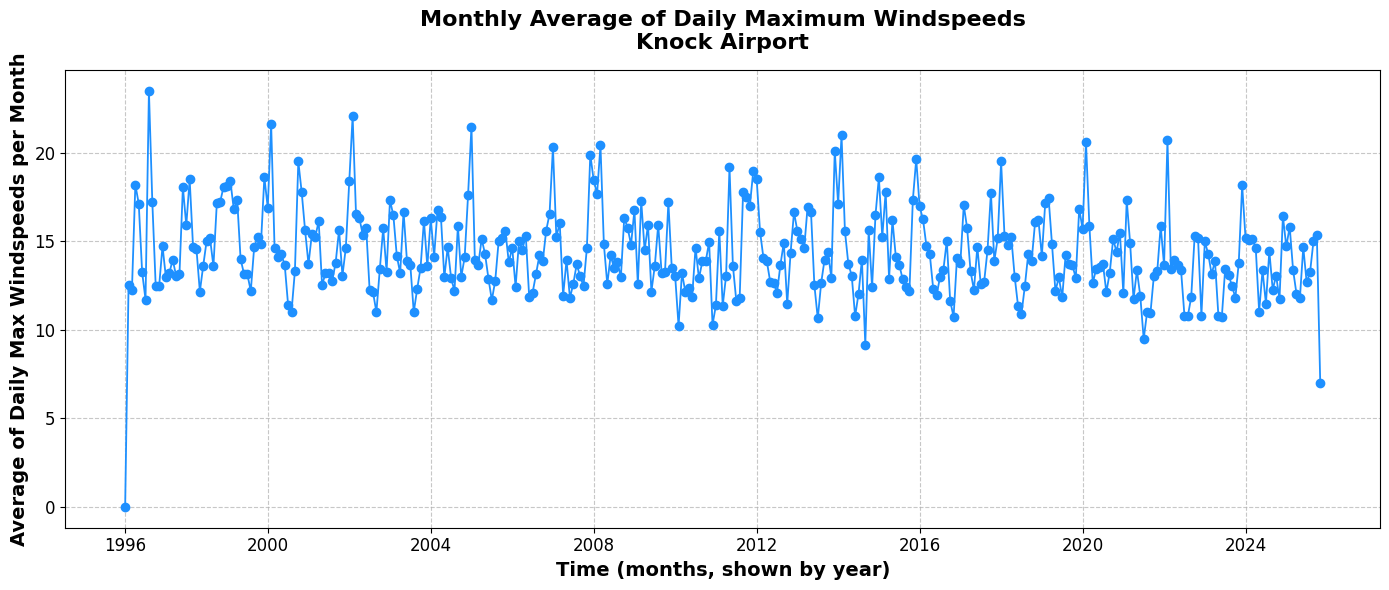

In [17]:
# Compute the maximum windspeed for each day
max_wdsp_per_day = df_wdsp.groupby(df_wdsp["date"].dt.strftime("%Y-%m-%d"))["wdsp"].max()

# Convert the index to datetime objects for easier plotting and grouping
max_wdsp_per_day.index = pd.to_datetime(max_wdsp_per_day.index, format="%Y-%m-%d")

# Convert the Series to a DataFrame
max_wdsp_per_day_df = max_wdsp_per_day.to_frame()

# Compute the monthly average of daily maximum windspeeds
max_wdsp_per_month = max_wdsp_per_day_df.groupby(max_wdsp_per_day_df.index.strftime("%Y-%m"))["wdsp"].mean()

# Extract the year from each "YYYY-MM" string in the index
years = [year_month.split("-")[0] for year_month in max_wdsp_per_month.index]

# Define which years to show as x-axis ticks (every 4 years)
years_to_plot = list(range(1996, 2025, 4))

# Find the positions in the index corresponding to the selected years
tick_positions = [years.index(str(y)) for y in years_to_plot]

# Set figure size for better visibility
plt.figure(figsize=(14, 6))

# Plot the monthly average of daily max windspeeds
plt.plot(max_wdsp_per_month.index, max_wdsp_per_month.values, 
         color='dodgerblue', linewidth=1.3, marker='o')  # added markers for clarity

# Set x-axis ticks to selected years
plt.xticks(tick_positions, years_to_plot, fontsize=12)

# Set y-axis font size
plt.yticks(fontsize=12)

# Add axis labels 
plt.ylabel("Average of Daily Max Windspeeds per Month", fontsize=14, weight='bold')
plt.xlabel("Time (months, shown by year)", fontsize=14, weight='bold')

# Add a title 
plt.title("Monthly Average of Daily Maximum Windspeeds\nKnock Airport", fontsize=16, weight='bold', pad=15)

# Add a light grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
